In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pingouin as pg


In [2]:
# get all data, combine to only 2dfs
df_sp = pd.read_csv("./toxdect/sp_toxdect_v6.csv")
df_sp = df_sp.drop(columns= "Unnamed: 0")
df_fg = pd.read_csv("./toxdect/fg_toxdect.csv")
df_sp_tg = pd.read_csv("./toxigen/sp_toxdect_toxigen.csv")
df_fg_tg = pd.read_csv("./toxigen/fg_toxdect_toxigen.csv")

df_sp["prob_tg"] = df_sp_tg["prob"]
df_fg["prob_tg"] = df_fg_tg["prob"]

df_sp = df_sp.rename(columns = {"prob": "prob_td"})
df_fg = df_fg.rename(columns = {"prob": "prob_td"})

# assign classes for later stats testing
df_sp["class_tg"] = np.where(df_sp["prob_tg"] > 90, 1, 0)
df_sp["class_td"] = np.where(df_sp["prob_td"] > 90, 1, 0)
df_fg["class_tg"] = np.where(df_fg["prob_tg"] > 90, 1, 0)
df_fg["class_td"] = np.where(df_fg["prob_td"] > 90, 1, 0)

df_sp["class_tg"] =  df_sp["class_tg"].astype(int)
df_sp["class_td"] = df_sp["class_td"].astype(int)
df_sp.head()




,Season,Episode,Character,Line,prob_td,prob_tg,class_tg,class_td
0,10,1,Stan,you guys you guys chef is going away,0.145919,0.098147,0,0
1,10,1,Kyle,going away for how long,0.084843,0.073145,0,0
2,10,1,Stan,forever,0.109894,0.133200,0,0
3,10,1,Chef,im sorry boys,0.152873,0.237865,0,0
4,10,1,Stan,chef said hes been bored so he joining a group...,0.201497,0.079151,0,0


In [3]:
for i, df in enumerate([df_sp, df_fg]):
    df = df[df["Episode"] != "Episode"] # make sure episode is a number
    df = df[df["Season"] != "Season"]  # Keep only numeric season values

    df = df[~df['Line'].isna()]  # Remove blank lines

    # Assign offensiveness class
    df["class_td"] = np.where(df["prob_td"] > 90, 1, 0)
    df["class_tg"] = np.where(df["prob_tg"] > 90, 1, 0)


    # Ensure season and episode are integer types
    df["Episode"] = df["Episode"].astype(int)
    df["Season"] = df["Season"].astype(int)

    # Remove lines that are <= 3 words
    df["split_line"] = df["Line"].str.split().apply(lambda x: [word for word in x if word.strip() != ""])
    df["line_len"] = df["split_line"].apply(len)
    df = df[df["line_len"] > 3]

    # Reassign the modified DataFrame back
    if i == 0:
        df_sp = df
    else:
        df_fg = df

df_sp.head()

,Season,Episode,Character,Line,prob_td,prob_tg,class_tg,class_td,split_line,line_len
0,10,1,Stan,you guys you guys chef is going away,0.145919,0.098147,0,0,"[you, guys, you, guys, chef, is, going, away]",8
1,10,1,Kyle,going away for how long,0.084843,0.073145,0,0,"[going, away, for, how, long]",5
4,10,1,Stan,chef said hes been bored so he joining a group...,0.201497,0.079151,0,0,"[chef, said, hes, been, bored, so, he, joining...",15
6,10,1,Mrs. Garrison,chef what kind of questions do you think adven...,0.079381,0.065412,0,0,"[chef, what, kind, of, questions, do, you, thi...",15
7,10,1,Chef,whats the meaning of life why are we here,0.109248,0.203369,0,0,"[whats, the, meaning, of, life, why, are, we, ...",9


In [ ]:
# save lines to examine
df_filt = df_sp.loc[df_sp['class_td'] != df_sp['class_tg']]
df_filt.to_excel("sp_classification_diff.xlsx")

In [7]:
# get season means for south park
sp_season_means = df_sp.groupby('Season')[['prob_td', 'prob_tg']].mean().reset_index()
sp_season_means = sp_season_means.sort_values(by=['Season'])
sp_season_means["year"] = list(range(1997, 2015))
sp_season_means['x'] = range(len(sp_season_means))

In [5]:
# get season means for family guy
fg_season_means = df_fg.groupby('Season')[['prob_td', 'prob_tg']].mean().reset_index()
fg_season_means = fg_season_means.sort_values(by=['Season'])
# need to account for skipped years
fg_season_means["year"] = [1999, 2000, 2001, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
fg_season_means['x'] = range(len(fg_season_means))

In [18]:
# list of episodes that are low outliers, high outliers, high diff btw models
sp_ep_means = df_sp.groupby(['Season', 'Episode'])[['prob_td', 'prob_tg']].mean().reset_index()

low_out_td = sp_ep_means.sort_values(by = 'prob_td', ascending = True).iloc[1:11][['Season','Episode']]
low_out_td = list(zip(low_out_td['Season'], low_out_td['Episode']))
low_out_tg = sp_ep_means.sort_values(by = 'prob_tg', ascending = True).iloc[1:11][['Season','Episode']]
low_out_tg = list(zip(low_out_tg['Season'], low_out_tg['Episode']))
high_out_td = sp_ep_means.sort_values(by = 'prob_td', ascending = False).iloc[1:11][['Season','Episode']]
high_out_td = list(zip(high_out_td['Season'], high_out_td['Episode']))
high_out_tg = sp_ep_means.sort_values(by = 'prob_tg', ascending = False).iloc[1:11][['Season','Episode']]
high_out_tg = list(zip(high_out_tg['Season'], high_out_tg['Episode']))
sp_ep_means["diff"] = abs(sp_ep_means["prob_tg"] - sp_ep_means["prob_td"])
high_diff = sp_ep_means.sort_values(by = 'diff', ascending = False).iloc[1:11][['Season','Episode']]
high_diff = list(zip(high_diff['Season'], high_diff['Episode']))
print(f"Low outliers toxdect: {low_out_td}")
print(f"Low outliers toxigen: {low_out_tg}")
print(f"High outliers toxdect: {high_out_td}")
print(f"High outliers toxigen: {high_out_tg}")
print(f"High model difference: {high_diff}")

Low outliers toxdect: [(6, 15), (8, 11), (7, 3), (12, 6), (15, 13), (8, 13), (6, 2), (9, 8), (9, 13), (5, 14)]
Low outliers toxigen: [(5, 14), (10, 14), (9, 14), (5, 13), (6, 15), (16, 7), (12, 12), (9, 8), (8, 11), (11, 13)]
High outliers toxdect: [(13, 12), (15, 4), (14, 1), (1, 5), (14, 8), (13, 9), (8, 8), (11, 8), (1, 6), (12, 9)]
High outliers toxigen: [(13, 12), (1, 5), (14, 1), (8, 8), (13, 9), (15, 4), (14, 8), (14, 9), (15, 6), (12, 8)]
High model difference: [(12, 14), (13, 12), (14, 9), (7, 10), (7, 2), (1, 13), (15, 5), (3, 14), (6, 4), (5, 1)]


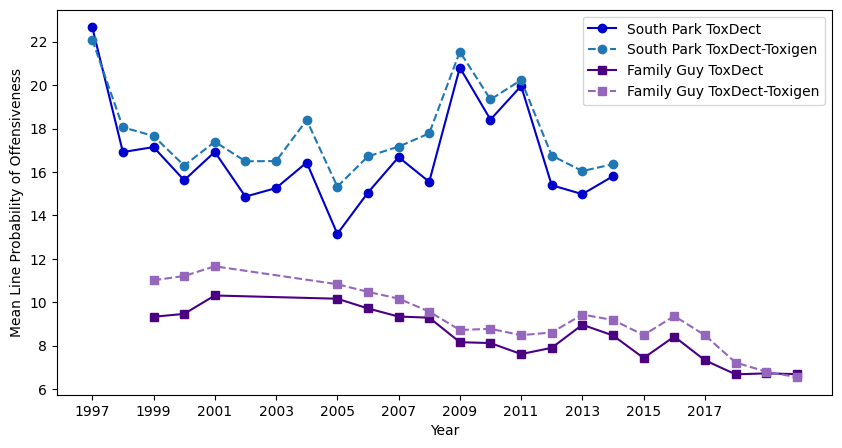

In [8]:
# Both shows side by side for both models
plt.figure(figsize=(10, 5))
plt.plot(sp_season_means["year"], sp_season_means["prob_td"], marker='o', linestyle='-', label="South Park ToxDect", color='mediumblue')
plt.plot(sp_season_means["year"], sp_season_means["prob_tg"], marker='o', linestyle='--', label="South Park ToxDect-Toxigen", color='tab:blue')
plt.plot(fg_season_means["year"], fg_season_means["prob_td"], marker='s', linestyle='-', label="Family Guy ToxDect", color='indigo')
plt.plot(fg_season_means["year"], fg_season_means["prob_tg"], marker='s', linestyle='--', label="Family Guy ToxDect-Toxigen", color='tab:purple')

# Labels, Title, and Legend
plt.xlabel("Year")
plt.xticks(range(1997, 2018, 2))
plt.ylabel("Mean Line Probability of Offensiveness")
plt.legend()
plt.show()

In [9]:
# data transformation for graphs comparing LIWC and ML models
fg_liwc = pd.read_csv("./liwc/fg_all_liwc.csv")
sp_liwc = pd.read_csv("./liwc/sp_all_liwc.csv")
metrics = ["swear", "sexual", "tone_neg", "Politics_Direction"]
sp_season_means_liwc = sp_liwc.groupby('Season')[metrics].mean().reset_index()
sp_season_means_liwc = sp_season_means_liwc.sort_values(by=['Season'])
fg_season_means_liwc = fg_liwc.groupby('Season')[metrics].mean().reset_index()
fg_season_means_liwc = fg_season_means_liwc.sort_values(by=['Season'])

# average btw td and tg models
sp_season_means = sp_season_means.sort_values(by=['Season'])
sp_season_means["prob_avg"] = sp_season_means[["prob_tg", "prob_td"]].mean(axis=1)
sp_season_means[metrics] = sp_season_means_liwc[metrics]

fg_season_means = fg_season_means.sort_values(by=['Season'])
fg_season_means["prob_avg"] = fg_season_means[["prob_tg", "prob_td"]].mean(axis=1)
fg_season_means[metrics] = fg_season_means_liwc[metrics]

# rescaling via min max scaling
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

sp_season_means['scaled_prob_avg'] = min_max_scale(sp_season_means['prob_avg'])
sp_season_means['scaled_swear'] = min_max_scale(sp_season_means['swear'])
sp_season_means['scaled_sexual'] = min_max_scale(sp_season_means['sexual'])
sp_season_means['scaled_politics'] = min_max_scale(sp_season_means['Politics_Direction'])

fg_season_means['scaled_prob_avg'] = min_max_scale(fg_season_means['prob_avg'])
fg_season_means['scaled_swear'] = min_max_scale(fg_season_means['swear'])
fg_season_means['scaled_sexual'] = min_max_scale(fg_season_means['sexual'])
fg_season_means['scaled_politics'] = min_max_scale(fg_season_means['Politics_Direction'])

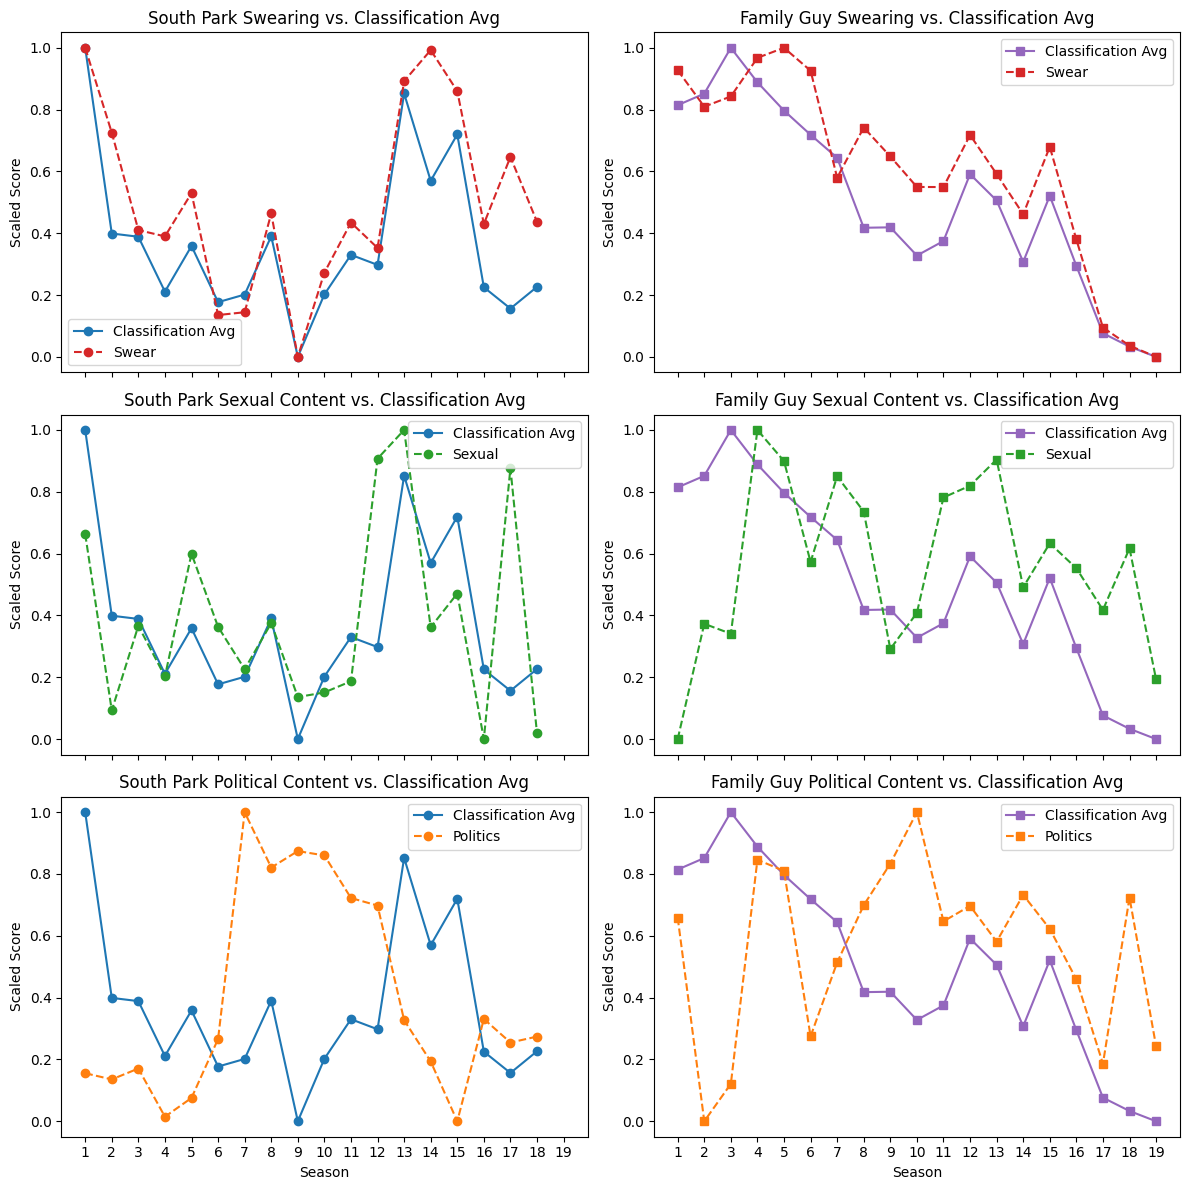

In [10]:

fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)

metrics = ["scaled_swear", "scaled_sexual", "scaled_politics"]
titles = ["Swearing vs. Classification Avg", 
          "Sexual Content vs. Classification Avg", 
          "Political Content vs. Classification Avg"]
colors = {
    "scaled_swear": "tab:red",      # Swearing → Red
    "scaled_sexual": "tab:green",  # Sexual → Orange
    "scaled_politics": "tab:orange"  # Politics → Green
}

# Loop through and plot for both SP and FG in separate columns
for row, (metric, title) in enumerate(zip(metrics, titles)):
    # Left column: South Park
    axes[row, 0].plot(sp_season_means["Season"], sp_season_means["scaled_prob_avg"], marker='o', linestyle='-', label="Classification Avg", color="tab:blue")
    axes[row, 0].plot(sp_season_means["Season"], sp_season_means[metric], marker='o', linestyle='--', label=f"{metric.split('_')[1].capitalize()}", color=colors[metric])
    axes[row, 0].set_ylabel("Scaled Score")
    axes[row, 0].set_title(f"South Park {title}")
    axes[row, 0].legend()

    # Right column: Family Guy
    axes[row, 1].plot(fg_season_means["Season"], fg_season_means["scaled_prob_avg"], marker='s', linestyle='-', label="Classification Avg", color="tab:purple")
    axes[row, 1].plot(fg_season_means["Season"], fg_season_means[metric], marker='s', linestyle='--', label=f"{metric.split('_')[1].capitalize()}", color=colors[metric])
    axes[row, 1].set_ylabel("Scaled Score")
    axes[row, 1].set_title(f"Family Guy {title}")
    axes[row, 1].legend()

# Common x-axis label
for ax in axes[-1, :]:
    ax.set_xlabel("Season")
    ax.set_xticks(range(1, 20))  # Adjust this if seasons go beyond 18

# Adjust layout
plt.tight_layout()
plt.show()


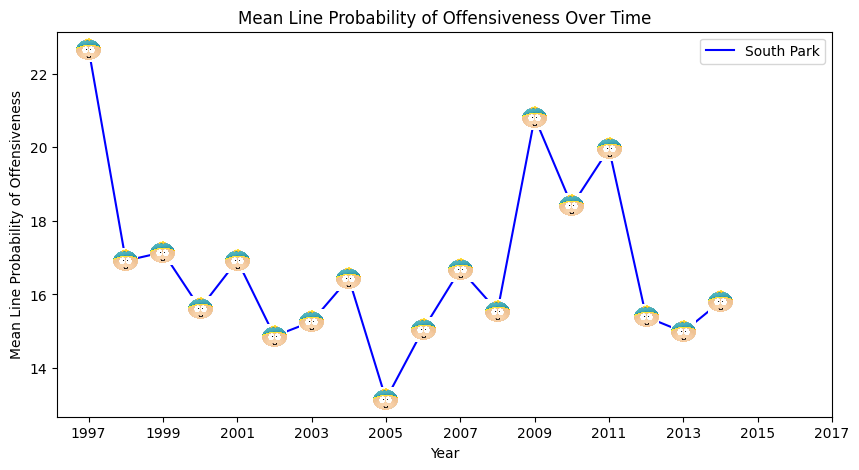

In [70]:
# messing around with the graphs
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Load custom marker images
sp_marker = mpimg.imread("sp_marker.jpg") 
fg_marker = mpimg.imread("fg_marker.png") 

# Function to place image at each data point
def add_custom_markers(ax, x_values, y_values, image, zoom):
    for x, y in zip(x_values, y_values):
        im = OffsetImage(image, zoom=zoom)  # Adjust zoom as needed
        ab = AnnotationBbox(im, (x, y), frameon=False)
        ax.add_artist(ab)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot lines (without markers)
ax.plot(sp_season_means["year"], sp_season_means["prob"], linestyle='-', label="South Park", color='blue')
#ax.plot(fg_season_means["year"], fg_season_means["prob"], linestyle='-', label="Family Guy", color='red')

# Add custom markers
add_custom_markers(ax, sp_season_means["year"], sp_season_means["prob"], sp_marker, 0.08)
#add_custom_markers(ax, fg_season_means["year"], fg_season_means["prob"], fg_marker, 0.04)

# Customize x-axis ticks every 2 years
ax.set_xticks(range(1997, 2018, 2))

# Labels, Title, and Legend
ax.set_xlabel("Year")
ax.set_ylabel("Mean Line Probability of Offensiveness")
ax.set_title("Mean Line Probability of Offensiveness Over Time")
ax.legend()

plt.show()


In [21]:
# Fisher tests for class differences btw diff models
from scipy.stats import fisher_exact

# compares btw class_td and class_tg
def fisher_test(df, season):
    # for both make sure class is int type
    df_filtered = df[df['Season'] == season]
    table = pd.DataFrame({
        'class_td': df_filtered['class_td'].value_counts(),
        'class_tg': df_filtered['class_tg'].value_counts()
    }).fillna(0).astype(int)

    if table.shape != (2, 2): # check table shape
        raise ValueError("Fisher's exact test requires a 2x2 contingency table.")

    oddsratio, p = fisher_exact(table)
    return oddsratio, p, table

pvals_sp = pd.DataFrame({"season": [], "pval": []})

# get fisher tests for every consecutive season pair
for i in range (1, len(df_sp["Season"].unique())):
    odds_ratio, p_value, table = fisher_test(df_sp, i)
    pvals_sp.loc[len(pvals_sp)] = [i, p_value]

# apply holm correction
# pvals_sp = pvals_sp.sort_values(by = "pval", ascending = False)
# pvals_sp["rank"] = range(1, len(pvals_sp)+1)
# pvals_sp["holm_pval"] = pvals_sp["pval"] * pvals_sp["rank"]
# pvals_sp["significant"] = pvals_sp["holm_pval"]< 0.05

pvals_sp

,season,pval
0,1.0,6.195642e-13
1,2.0,1.817884e-09
2,3.0,1.076723e-10
3,4.0,1.354634e-12
4,5.0,1.454668e-10
5,6.0,3.962849e-09
6,7.0,2.218921e-07
7,8.0,4.291440e-07
8,9.0,1.328903e-04
9,10.0,5.026312e-07
